In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from pyLIMA.outputs import pyLIMA_plots
from cycler import cycler
import pandas as pd
sys.path.append(os.path.dirname(os.getcwd()))
from functions_roman_rubin_old import sim_fit,sim_event
# from functions_roman_bonnie bluerubin import model_rubin_roman
from functions_roman_rubin_old import read_data, save_sim
from fit_lc import fit_rubin_roman, model_rubin_roman
from astropy import units as u

In [3]:
import re

# print(num) 


In [4]:
from class_analysis import Analysis_Event
path_to_save_model = '/mnt/almacenamiento/FFP_local/FFP/set_sim1/'
path_to_save_fit = '/mnt/almacenamiento/FFP_local/FFP/set_fit1/'
files_sim = [file for file in os.listdir(path_to_save_model) if "h5" in file]
model = "FSPL" 
for i in range(len(files_sim)):
    try:
        nevent = int(re.search(r'\d+', files_sim[i]).group())
        Event = Analysis_Event(model, path_to_save_model+'/Event_'+str(int(nevent))+'.h5',
                                   path_to_save_fit+f'/Event_RR_{ nevent }_TRF.npy', 
                                   path_to_save_fit+f'/Event_Roman_{ nevent }_TRF.npy')
        Event.load_data_fit()
        Event.load_data_sim()
        
        data_fit_rr = Event.fit_rr_data
        data_fit_roman = Event.fit_roman_data
        
        pyLIMA_parameters = Event.model_params
        print("********************Evento ", nevent, "***************")
        print("tE", pyLIMA_parameters['tE'])
        bands = Event.lightcurves
        
        origin = Event.info[2]
        PAR = Event.labels_params()
        
        chi2_rr = Event.chichi_dof(Event.fit_rr_data)['chi2']
        DOF_rr = Event.chichi_dof(Event.fit_rr_data)["dof"]
        
        chi2_roman =  Event.chichi_dof(Event.fit_roman_data)['chi2']
        DOF_roman = Event.chichi_dof(Event.fit_roman_data)['dof']
        
        dict_fit_roman = Event.dict_fit_vals(Event.fit_roman_data) 
        dict_fit_rr = Event.dict_fit_vals(Event.fit_rr_data)

        for p in ['u0','t0','piEE','piEN']:
    
            if (abs(dict_fit_rr["piEE_err"]/dict_fit_rr["piEE"]) <1) or (abs(dict_fit_rr["piEN_err"]/dict_fit_rr["piEN"]) <1):
                print(p)
                print("(p-p_fit)/sigma",(pyLIMA_parameters[p] - dict_fit_rr[p])/dict_fit_rr[p+'_err'])
                print("sigma/p_fit",dict_fit_rr[p+"_err"]/dict_fit_rr[p])
                print("(p-p_fit)/p",(pyLIMA_parameters[p] - dict_fit_rr[p])/dict_fit_rr[p])
        
        delta_t0 = pyLIMA_parameters['piEE']*0.01*pyLIMA_parameters['tE']
        print(delta_t0)
        
        print("Dt0 > sigma_t0(Roman)", abs(delta_t0) >= dict_fit_roman['t0_err'])
        print("Dt0 > sigma_t0(RR)", abs(delta_t0) >= dict_fit_rr['t0_err'])
    except:
        print("No se completo el fit")

********************Evento  61 ***************
tE 1.5230062212846993
0.009930693233923944
Dt0 > sigma_t0(Roman) False
Dt0 > sigma_t0(RR) False
********************Evento  42 ***************
tE 2.47256111612638
0.005080386789728465
Dt0 > sigma_t0(Roman) False
Dt0 > sigma_t0(RR) False
********************Evento  104 ***************
tE 0.8211284768322274
u0
(p-p_fit)/sigma -inf
sigma/p_fit -0.0
(p-p_fit)/p 1.611665743450957
t0
(p-p_fit)/sigma inf
sigma/p_fit 0.0
(p-p_fit)/p 2.1387144210629194e-06
piEE
(p-p_fit)/sigma inf
sigma/p_fit 0.0
(p-p_fit)/p 0.9587867205912235
piEN
(p-p_fit)/sigma -inf
sigma/p_fit -0.0
(p-p_fit)/p 6.0442547775684305
0.0005715279265069411
Dt0 > sigma_t0(Roman) False
Dt0 > sigma_t0(RR) True
********************Evento  59 ***************
tE 0.532879797198293
-0.0005164464634664501
Dt0 > sigma_t0(Roman) False
Dt0 > sigma_t0(RR) False
********************Evento  58 ***************
tE 7.679227629621441
u0
(p-p_fit)/sigma -inf
sigma/p_fit -0.0
(p-p_fit)/p 0.41556990535292

In [5]:
nevent = 475

Event = Analysis_Event(model, path_to_save_model+'/Event_'+str(int(nevent))+'.h5',
                           path_to_save_fit+f'/Event_RR_{ nevent }_TRF.npy', 
                           path_to_save_fit+f'/Event_Roman_{ nevent }_TRF.npy')
Event.load_data_fit()
Event.load_data_sim()

data_fit_rr = Event.fit_rr_data
data_fit_roman = Event.fit_roman_data

pyLIMA_parameters = Event.model_params
print('tE', pyLIMA_parameters['tE'])
bands = Event.lightcurves

origin = Event.info[2]
PAR = Event.labels_params()

chi2_rr = Event.chichi_dof(Event.fit_rr_data)['chi2']
DOF_rr = Event.chichi_dof(Event.fit_rr_data)["dof"]

chi2_roman =  Event.chichi_dof(Event.fit_roman_data)['chi2']
DOF_roman = Event.chichi_dof(Event.fit_roman_data)['dof']

dict_fit_roman = Event.dict_fit_vals(Event.fit_roman_data) 
dict_fit_rr = Event.dict_fit_vals(Event.fit_rr_data)

for p in ['u0','t0','piEE','piEN']:
    print('p = ', p)
    print("(p-p_fit)/sigma",(pyLIMA_parameters[p] - dict_fit_rr[p])/dict_fit_rr[p+'_err'])
    print("sigma/p_fit",dict_fit_rr[p+"_err"]/dict_fit_rr[p])
    print("(p-p_fit)/p",(pyLIMA_parameters[p] - dict_fit_rr[p])/dict_fit_rr[p])

delta_t0 = pyLIMA_parameters['piEE']*0.01*pyLIMA_parameters['tE']
# print(delta_t0)
print("Dt0 > sigma_t0(Roman)", abs(delta_t0) >= dict_fit_roman['t0_err'])
print("Dt0 > sigma_t0(RR)", abs(delta_t0) >= dict_fit_rr['t0_err'])


delta_u0 = pyLIMA_parameters['piEN']*0.01
# print(delta_u0)
# print(dict_fit_rr['u0_err'])
print("Du0 > sigma_u0(Roman)", abs(delta_u0) >= dict_fit_roman['u0_err'])
print("Du0 > sigma_u0(RR)", abs(delta_u0) >= dict_fit_rr['u0_err'])

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/almacenamiento/FFP_local/FFP/set_fit1//Event_RR_475_TRF.npy'

In [6]:
for p in ['u0','t0','piEE','piEN']:
    print(p)
    print("(p-p_fit)/sigma",(pyLIMA_parameters[p] - dict_fit_roman[p])/dict_fit_roman[p+'_err'])
    print("sigma/p_fit",dict_fit_roman[p+"_err"]/dict_fit_roman[p])
    print("(p-p_fit)/p",(pyLIMA_parameters[p] - dict_fit_roman[p])/dict_fit_roman[p])


u0
(p-p_fit)/sigma 0.0004263697034976401
sigma/p_fit -724.2147355168933
(p-p_fit)/p -0.30878322205095965
t0
(p-p_fit)/sigma -0.04327780877760027
sigma/p_fit 1.4871445902037094e-05
(p-p_fit)/p -6.436035919947885e-07
piEE
(p-p_fit)/sigma 5.461499892282415e-07
sigma/p_fit -564492.5857511057
(p-p_fit)/p -0.30829761962738855
piEN
(p-p_fit)/sigma 5.558530830868696e-07
sigma/p_fit 2031774.6860660315
(p-p_fit)/p 1.12936822338766


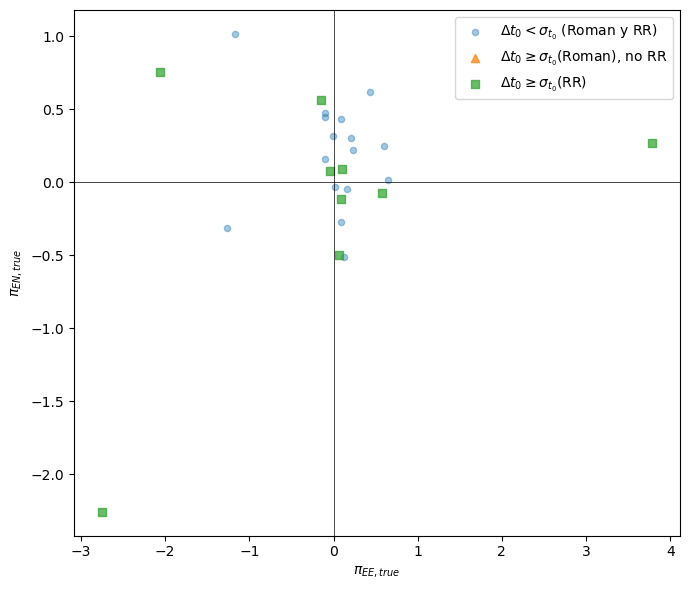

In [7]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from class_analysis import Analysis_Event

# ----------------- paths y configuración -----------------
path_to_save_model = '/mnt/almacenamiento/FFP_local/FFP/set_sim1/'
path_to_save_fit   = '/mnt/almacenamiento/FFP_local/FFP/set_fit1/'
files_sim = [file for file in os.listdir(path_to_save_model) if file.endswith(".h5")]

model = "FSPL"

# Separación proyectada típica L2–Tierra (en AU) para estimar Δt0
D_perp_ref = 0.01   # poné aquí el valor que estés usando en tus cálculos

# Listas para el gráfico
piEE_true_list = []
piEN_true_list = []

# flags de "paralaje medible" según condición en Δt0
good_parallax_rr    = []  # condición cumplida con RR (Roman+Rubin)
good_parallax_roman = []  # condición cumplida con Roman solo

# opcional: guardar alguna métrica de calidad
sigma_t0_rr_list    = []
sigma_t0_roman_list = []
delta_t0_list       = []

# ----------------- loop sobre eventos -----------------
for fname in files_sim:
    try:
        nevent = int(re.search(r'\d+', fname).group())

        Event = Analysis_Event(
            model,
            os.path.join(path_to_save_model, f'Event_{nevent}.h5'),
            os.path.join(path_to_save_fit,   f'Event_RR_{nevent}_TRF.npy'),
            os.path.join(path_to_save_fit,   f'Event_Roman_{nevent}_TRF.npy'),
        )

        Event.load_data_fit()
        Event.load_data_sim()

        data_fit_rr    = Event.fit_rr_data
        data_fit_roman = Event.fit_roman_data
        pyLIMA_parameters = Event.model_params  # parámetros "verdaderos" de la simulación

        # valores verdaderos
        piEE_true = pyLIMA_parameters['piEE']
        piEN_true = pyLIMA_parameters['piEN']
        tE_true   = pyLIMA_parameters['tE']

        # diccionarios con fit y errores
        dict_fit_roman = Event.dict_fit_vals(data_fit_roman)
        dict_fit_rr    = Event.dict_fit_vals(data_fit_rr)

        # si falta algo, saltamos
        if any(k not in dict_fit_rr for k in ['t0_err', 'piEE', 'piEE_err', 'piEN', 'piEN_err']):
            print(f"Evento {nevent}: faltan parámetros en fit RR, se salta.")
            continue
        if any(k not in dict_fit_roman for k in ['t0_err']):
            print(f"Evento {nevent}: faltan parámetros en fit Roman, se salta.")
            continue

        # ------------- condición en Δt0 ----------------
        # Usamos Δt0 ≈ piEE_true * D_perp_ref * tE_true
        delta_t0 = piEE_true * D_perp_ref * tE_true  # en las mismas unidades que t0 (días)
        sigma_t0_rr    = dict_fit_rr['t0_err']
        sigma_t0_roman = dict_fit_roman['t0_err']

        # banderas: ¿cumple |Δt0| >= σ_t0?
        cond_rr    = np.abs(delta_t0) >= sigma_t0_rr
        cond_roman = np.abs(delta_t0) >= sigma_t0_roman

        # guardamos para el gráfico
        piEE_true_list.append(piEE_true)
        piEN_true_list.append(piEN_true)
        good_parallax_rr.append(cond_rr)
        good_parallax_roman.append(cond_roman)
        sigma_t0_rr_list.append(sigma_t0_rr)
        sigma_t0_roman_list.append(sigma_t0_roman)
        delta_t0_list.append(delta_t0)

    except Exception as e:
        print(f"No se completó el fit para {fname}: {e}")
        continue

piEE_true_arr = np.array(piEE_true_list)
piEN_true_arr = np.array(piEN_true_list)
good_parallax_rr    = np.array(good_parallax_rr, dtype=bool)
good_parallax_roman = np.array(good_parallax_roman, dtype=bool)
delta_t0_arr        = np.array(delta_t0_list)
sigma_t0_rr_arr     = np.array(sigma_t0_rr_list)
sigma_t0_roman_arr  = np.array(sigma_t0_roman_list)

# ----------------- Gráfico en plano (piEE, piEN) -----------------
plt.figure(figsize=(7, 6))

# 1) eventos donde NO se cumple la condición en ninguna de las curvas
mask_bad = ~(good_parallax_rr | good_parallax_roman)

plt.scatter(
    piEE_true_arr[mask_bad],
    piEN_true_arr[mask_bad],
    s=20,
    marker='o',
    alpha=0.4,
    label=r'$\Delta t_0 < \sigma_{t_0}$ (Roman y RR)'
)

# 2) eventos donde se cumple solo con Roman
mask_only_roman = good_parallax_roman & ~good_parallax_rr
plt.scatter(
    piEE_true_arr[mask_only_roman],
    piEN_true_arr[mask_only_roman],
    s=35,
    marker='^',
    alpha=0.7,
    label=r'$\Delta t_0 \geq \sigma_{t_0}$(Roman), no RR'
)

# 3) eventos donde se cumple con RR (puede incluir también Roman)
mask_rr = good_parallax_rr
plt.scatter(
    piEE_true_arr[mask_rr],
    piEN_true_arr[mask_rr],
    s=35,
    marker='s',
    alpha=0.7,
    label=r'$\Delta t_0 \geq \sigma_{t_0}$(RR)'
)

plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)

plt.xlabel(r'$\pi_{{EE,true}}$')
plt.ylabel(r'$\pi_{{EN,true}}$')
# plt.title(r'Eventos en el plano $(\pi_{{EE}}, \pi_{{EN}})$' '\n'
#           r'Condición $|\Delta t_0| \gtrsim \sigma_{t_0}$ para medir paralaje')
plt.legend()
plt.tight_layout()
plt.show()


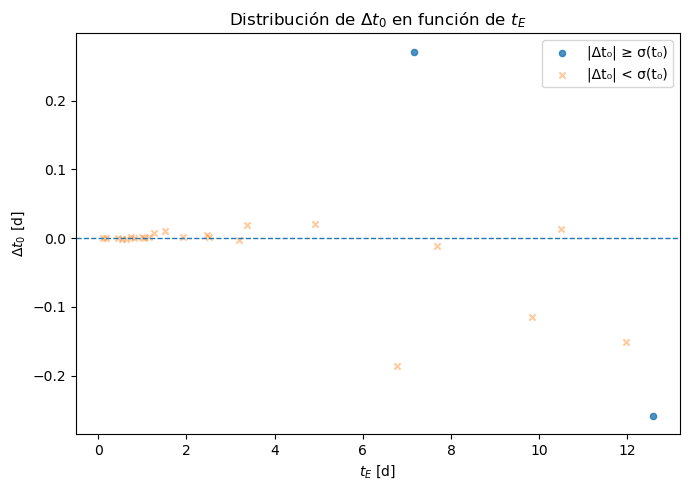

In [8]:
import os, re
import numpy as np
import matplotlib.pyplot as plt
from class_analysis import Analysis_Event

path_to_save_model = '/mnt/almacenamiento/FFP_local/FFP/set_sim1/'
path_to_save_fit   = '/mnt/almacenamiento/FFP_local/FFP/set_fit1/'
files_sim = [file for file in os.listdir(path_to_save_model) if "h5" in file]
model = "FSPL"

tE_all       = []
delta_t0_all = []
ok_mask      = []   # por ejemplo, si querés marcar cuándo |Δt0| > sigma_t0

for fname in files_sim:
    try:
        nevent = int(re.search(r'\d+', fname).group())
        Event = Analysis_Event(
            model,
            os.path.join(path_to_save_model, f'Event_{nevent}.h5'),
            os.path.join(path_to_save_fit,   f'Event_RR_{nevent}_TRF.npy'),
            os.path.join(path_to_save_fit,   f'Event_Roman_{nevent}_TRF.npy'),
        )
        Event.load_data_fit()
        Event.load_data_sim()

        pyLIMA_parameters = Event.model_params
        dict_fit_rr    = Event.dict_fit_vals(Event.fit_rr_data)
        dict_fit_roman = Event.dict_fit_vals(Event.fit_roman_data)

        tE_true = pyLIMA_parameters['tE']

        # Suponiendo D_perp ≈ 0.01 AU como antes
        delta_t0 = pyLIMA_parameters['piEE'] * 0.01 * tE_true

        # guardamos para el scatter
        tE_all.append(tE_true)
        delta_t0_all.append(delta_t0)

        # ejemplo de máscara: si |Δt0| > sigma_t0 (de Roman, por ej.)
        ok_mask.append(np.abs(delta_t0) >= dict_fit_roman['t0_err'])

    except Exception as e:
        print(f"No se completó el fit para {fname}: {e}")

tE_all       = np.array(tE_all)
delta_t0_all = np.array(delta_t0_all)
ok_mask      = np.array(ok_mask, dtype=bool)

plt.figure(figsize=(7,5))

# puntos donde la condición se cumple
plt.scatter(tE_all[ok_mask], delta_t0_all[ok_mask],
            s=20, alpha=0.8, label='|Δt₀| ≥ σ(t₀)', marker='o')

# puntos donde NO se cumple
plt.scatter(tE_all[~ok_mask], delta_t0_all[~ok_mask],
            s=20, alpha=0.4, label='|Δt₀| < σ(t₀)', marker='x')

plt.axhline(0, ls='--', lw=1)

plt.xlabel(r'$t_E\ \mathrm{[d]}$')
plt.ylabel(r'$\Delta t_0\ \mathrm{[d]}$')
plt.title('Distribución de $\Delta t_0$ en función de $t_E$')
plt.legend(loc='best')

plt.tight_layout()
plt.show()


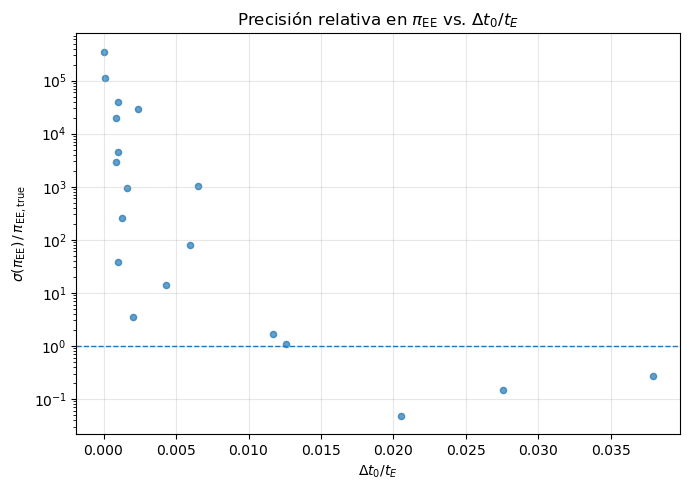

In [9]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from class_analysis import Analysis_Event

# ---- Paths y modelo ----
path_to_save_model = '/mnt/almacenamiento/FFP_local/FFP/set_sim1/'
path_to_save_fit   = '/mnt/almacenamiento/FFP_local/FFP/set_fit1/'
model = "FSPL"

files_sim = [f for f in os.listdir(path_to_save_model) if f.endswith(".h5")]

# ---- Parámetro geométrico asumido (puedes cambiarlo por D_perp real) ----
Dperp_ref = 0.01   # AU

# ---- Listas para el scatter ----
x_vals = []   # Delta t0 / tE
y_vals = []   # sigma_piEE / piEE_true

for fname in files_sim:
    try:
        nevent = int(re.search(r'\d+', fname).group())

        Event = Analysis_Event(
            model,
            os.path.join(path_to_save_model, f'Event_{nevent}.h5'),
            os.path.join(path_to_save_fit,  f'Event_RR_{nevent}_TRF.npy'),
            os.path.join(path_to_save_fit,  f'Event_Roman_{nevent}_TRF.npy'),
        )

        # Carga datos de fit y simulación
        Event.load_data_fit()
        Event.load_data_sim()

        pyLIMA_parameters = Event.model_params  # parámetros "verdaderos"
        dict_fit_rr = Event.dict_fit_vals(Event.fit_rr_data)  # fit Roman+Rubin

        # Parámetros verdaderos
        piEE_true = pyLIMA_parameters['piEE']
        tE_true   = pyLIMA_parameters['tE']

        # Error de piEE en el fit
        piEE_err  = dict_fit_rr['piEE_err']

        # Filtrado básico para evitar divisiones raras
        if (piEE_true == 0) or (not np.isfinite(piEE_true)) or (not np.isfinite(piEE_err)):
            continue

        # ---- Cálculo de Delta t0 y normalizaciones ----
        # Delta t0 ~ piEE_true * D_perp * tE_true
        delta_t0 = piEE_true * Dperp_ref * tE_true

        x = delta_t0 / tE_true                  # Delta t0 / tE
        y = piEE_err / piEE_true                # sigma_piEE / piEE_true

        if np.isfinite(x) and np.isfinite(y):
            x_vals.append(x)
            y_vals.append(y)

    except Exception as e:
        print(f"No se completó el fit para {fname}: {e}")
        continue

x_vals = np.array(x_vals)
y_vals = np.array(y_vals)

# ---- Gráfico ----
plt.figure(figsize=(7, 5))

plt.scatter(abs(x_vals), abs(y_vals), s=20, alpha=0.7)

# Línea horizontal en sigma_piEE / piEE_true = 1 como referencia
plt.axhline(1.0, ls='--', lw=1)

plt.xlabel(r'$\Delta t_0 / t_E$')
plt.ylabel(r'$\sigma(\pi_{\mathrm{EE}})\,/\,\pi_{\mathrm{EE,true}}$')

plt.title(r'Precisión relativa en $\pi_{\mathrm{EE}}$ vs. '
          r'$\Delta t_0 / t_E$')
plt.yscale("log")
# plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


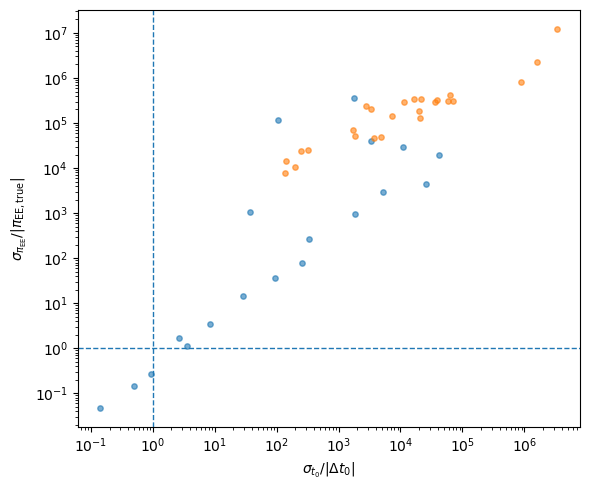

In [10]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from class_analysis import Analysis_Event

# --- paths y modelo (como en tu código) ---
path_to_save_model = '/mnt/almacenamiento/FFP_local/FFP/set_sim1/'
path_to_save_fit   = '/mnt/almacenamiento/FFP_local/FFP/set_fit1/'
files_sim = [file for file in os.listdir(path_to_save_model) if "h5" in file]
model = "FSPL"

# --- separación proyectada fija (en AU) que usabas antes ---
D_perp = 0.01   # puedes cambiarlo si tienes D_perp(t0) por evento

x_sigma_t0_over_Dt0 = []   # sigma_t0 / |Delta t0|
y_sigma_piEE_over_piEE = []  # sigma_piEE / |piEE_true|

x_sigma_t0_over_Dt0_roman = []   # sigma_t0 / |Delta t0|
y_sigma_piEE_over_piEE_roman = []  # sigma_piEE / |piEE_true|

for fname in files_sim:
    try:
        nevent = int(re.search(r'\d+', fname).group())

        Event = Analysis_Event(
            model,
            os.path.join(path_to_save_model, f'Event_{nevent}.h5'),
            os.path.join(path_to_save_fit,  f'Event_RR_{nevent}_TRF.npy'),
            os.path.join(path_to_save_fit,  f'Event_Roman_{nevent}_TRF.npy'),
        )

        Event.load_data_fit()
        Event.load_data_sim()

        pyLIMA_parameters = Event.model_params
        dict_fit_rr     = Event.dict_fit_vals(Event.fit_rr_data)

        # parámetros "verdaderos"
        tE_true   = pyLIMA_parameters['tE']
        piEE_true = pyLIMA_parameters['piEE']

        # errores del ajuste RR
        sigma_t0   = dict_fit_rr['t0_err']
        sigma_piEE = dict_fit_rr['piEE_err']
        
        # errores del ajuste Roman
        sigma_t0_roman   = dict_fit_roman['t0_err']
        sigma_piEE_roman = dict_fit_roman['piEE_err']

        # Delta t0 usando la aproximación que ya usabas: Δt0 = piEE * D_perp * tE
        delta_t0 = piEE_true * D_perp * tE_true

        # filtros básicos para evitar divisiones raras
        if (piEE_true == 0) or (delta_t0 == 0):
            continue
        if not np.isfinite(sigma_t0) or not np.isfinite(sigma_piEE):
            continue

        x = sigma_t0 / abs(delta_t0)
        x_roman = sigma_t0_roman / abs(delta_t0)
        y = abs(sigma_piEE / piEE_true)
        y_roman = abs(sigma_piEE_roman / piEE_true)

        if np.isfinite(x) and np.isfinite(y):
            x_sigma_t0_over_Dt0.append(x)
            y_sigma_piEE_over_piEE.append(y)

        if np.isfinite(x_roman) and np.isfinite(y_roman):
            x_sigma_t0_over_Dt0_roman.append(x_roman)
            y_sigma_piEE_over_piEE_roman.append(y_roman)

    except Exception as e:
        print(f"Evento {fname}: no se completó el fit ({e})")
        continue

x_sigma_t0_over_Dt0 = np.array(x_sigma_t0_over_Dt0)
y_sigma_piEE_over_piEE = np.array(y_sigma_piEE_over_piEE)

x_sigma_t0_over_Dt0_roman = np.array(x_sigma_t0_over_Dt0_roman)
y_sigma_piEE_over_piEE_roman = np.array(y_sigma_piEE_over_piEE_roman)

# --- gráfico ---
plt.figure(figsize=(6, 5))
plt.scatter(x_sigma_t0_over_Dt0, y_sigma_piEE_over_piEE, alpha=0.6, s=15)
plt.scatter(x_sigma_t0_over_Dt0_roman, y_sigma_piEE_over_piEE_roman, alpha=0.6, s=15)
# líneas guía en 1
plt.axvline(1.0, ls='--', lw=1)
plt.axhline(1.0, ls='--', lw=1)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$\sigma_{t_0} / |\Delta t_0|$')
plt.ylabel(r'$\sigma_{\pi_{\mathrm{EE}}} / |\pi_{\mathrm{EE,true}}|$')

# plt.title('Relación entre precisión en $t_0$ y en $\pi_{\mathrm{EE}}$')

plt.tight_layout()
plt.show()


In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from class_analysis import Analysis_Event

# --- paths y modelo (como en tu código) ---
path_to_save_model = '/mnt/almacenamiento/FFP_local/FFP/set_sim1/'
path_to_save_fit   = '/mnt/almacenamiento/FFP_local/FFP/set_fit1/'
files_sim = [file for file in os.listdir(path_to_save_model) if "h5" in file]
model = "FSPL"

# --- separación proyectada fija (en AU) que usabas antes ---
D_perp = 0.01   # puedes cambiarlo si tienes D_perp(t0) por evento

x_sigma_t0_over_Dt0 = []   # sigma_t0 / |Delta t0|
y_sigma_piEE_over_piEE = []  # sigma_piEE / |piEE_true|

x_sigma_t0_over_Dt0_roman = []   # sigma_t0 / |Delta t0|
y_sigma_piEE_over_piEE_roman = []  # sigma_piEE / |piEE_true|

for fname in files_sim:
    try:
        nevent = int(re.search(r'\d+', fname).group())

        Event = Analysis_Event(
            model,
            os.path.join(path_to_save_model, f'Event_{nevent}.h5'),
            os.path.join(path_to_save_fit,  f'Event_RR_{nevent}_TRF.npy'),
            os.path.join(path_to_save_fit,  f'Event_Roman_{nevent}_TRF.npy'),
        )

        Event.load_data_fit()
        Event.load_data_sim()

        pyLIMA_parameters = Event.model_params
        dict_fit_rr     = Event.dict_fit_vals(Event.fit_rr_data)

        # parámetros "verdaderos"
        tE_true   = pyLIMA_parameters['tE']
        piEE_true = pyLIMA_parameters['piEN']

        # errores del ajuste RR
        sigma_t0   = dict_fit_rr['u0_err']
        sigma_piEE = dict_fit_rr['piEN_err']
        
        # errores del ajuste Roman
        sigma_t0_roman   = dict_fit_roman['u0_err']
        sigma_piEE_roman = dict_fit_roman['piEN_err']

        # Delta t0 usando la aproximación que ya usabas: Δt0 = piEE * D_perp * tE
        delta_t0 = piEE_true * D_perp 

        # filtros básicos para evitar divisiones raras
        if (piEE_true == 0) or (delta_t0 == 0):
            continue
        if not np.isfinite(sigma_t0) or not np.isfinite(sigma_piEE):
            continue

        x = sigma_t0 / abs(delta_t0)
        x_roman = sigma_t0_roman / abs(delta_t0)
        y = abs(sigma_piEE / piEE_true)
        y_roman = abs(sigma_piEE_roman / piEE_true)

        if np.isfinite(x) and np.isfinite(y):
            x_sigma_t0_over_Dt0.append(x)
            y_sigma_piEE_over_piEE.append(y)

        if np.isfinite(x_roman) and np.isfinite(y_roman):
            x_sigma_t0_over_Dt0_roman.append(x_roman)
            y_sigma_piEE_over_piEE_roman.append(y_roman)

    except Exception as e:
        print(f"Evento {fname}: no se completó el fit ({e})")
        continue

x_sigma_t0_over_Dt0 = np.array(x_sigma_t0_over_Dt0)
y_sigma_piEE_over_piEE = np.array(y_sigma_piEE_over_piEE)

x_sigma_t0_over_Dt0_roman = np.array(x_sigma_t0_over_Dt0_roman)
y_sigma_piEE_over_piEE_roman = np.array(y_sigma_piEE_over_piEE_roman)

# --- gráfico ---
plt.figure(figsize=(6, 5))
plt.scatter(x_sigma_t0_over_Dt0, y_sigma_piEE_over_piEE, alpha=0.6, s=15)
plt.scatter(x_sigma_t0_over_Dt0_roman, y_sigma_piEE_over_piEE_roman, alpha=0.6, s=15)
# líneas guía en 1
plt.axvline(1.0, ls='--', lw=1)
plt.axhline(1.0, ls='--', lw=1)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$\sigma_{u_0} / |\Delta u_0|$')
plt.ylabel(r'$\sigma_{\pi_{\mathrm{EN}}} / |\pi_{\mathrm{EN,true}}|$')

# plt.title('Relación entre precisión en $t_0$ y en $\pi_{\mathrm{EE}}$')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re
import os

from class_analysis import Analysis_Event

path_to_save_model = '/mnt/almacenamiento/FFP_local/FFP/set_sim1/'
path_to_save_fit = '/mnt/almacenamiento/FFP_local/FFP/set_fit1/'

files_sim = [file for file in os.listdir(path_to_save_model) if "h5" in file]

sigma_t0_list = []
sigma_piEE_list = []

model = "FSPL"

for file in files_sim:
    try:
        nevent = int(re.search(r'\d+', file).group())

        Event = Analysis_Event(
            model,
            path_to_save_model + f'/Event_{nevent}.h5',
            path_to_save_fit + f'/Event_RR_{nevent}_TRF.npy',
            path_to_save_fit + f'/Event_Roman_{nevent}_TRF.npy'
        )

        Event.load_data_fit()
        Event.load_data_sim()

        dict_fit_rr = Event.dict_fit_vals(Event.fit_rr_data)

        # errores
        sigma_t0 = dict_fit_rr['t0_err']
        sigma_piEE = dict_fit_rr['piEE_err']

        # guardar
        if (sigma_t0 > 0) and (sigma_piEE > 0):
            sigma_t0_list.append(sigma_t0)
            sigma_piEE_list.append(sigma_piEE)

    except Exception as e:
        print("Evento fallido", file, e)
        continue

# convertir a arrays
sigma_t0_list = np.array(sigma_t0_list)
sigma_piEE_list = np.array(sigma_piEE_list)

# ------------- GRAFICO -------------
plt.figure(figsize=(8,6))

plt.scatter(
    sigma_piEE_list,
    sigma_t0_list,
    s=20, alpha=0.6
)

plt.xlabel(r'$\sigma_{\pi_{\mathrm{EE}}}$', fontsize=15)
plt.ylabel(r'$\sigma_{t_0}$  (day)', fontsize=15)

# plt.title(r'Dispersión entre $\sigma_{t_0}$ y $\sigma_{\pi_{\mathrm{EE}}}$',
          # fontsize=15)
plt.yscale("log")
plt.xscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import os, re
import numpy as np
import matplotlib.pyplot as plt
from class_analysis import Analysis_Event

path_to_save_model = '/mnt/almacenamiento/FFP_local/FFP/set_sim1/'
path_to_save_fit   = '/mnt/almacenamiento/FFP_local/FFP/set_fit1/'
files_sim = [file for file in os.listdir(path_to_save_model) if "h5" in file]

model = "FSPL"

sigma_rho_list   = []
sigma_piEE_list  = []

for fname in files_sim:
    try:
        nevent = int(re.search(r'\d+', fname).group())
        Event = Analysis_Event(
            model,
            os.path.join(path_to_save_model,  f'Event_{nevent}.h5'),
            os.path.join(path_to_save_fit,   f'Event_RR_{nevent}_TRF.npy'),
            os.path.join(path_to_save_fit,   f'Event_Roman_{nevent}_TRF.npy')
        )

        Event.load_data_fit()
        Event.load_data_sim()

        # Elegí con qué fit trabajar (RR o Roman); acá uso el combinado RR:
        dict_fit_rr = Event.dict_fit_vals(Event.fit_rr_data)

        # Asegurarnos de que existan las claves y que los errores sean finitos
        if all(k in dict_fit_rr for k in ['rho_err', 'piEE_err']):
            sig_rho  = dict_fit_rr['rho_err']/dict_fit_rr['rho']
            sig_piEE = abs(dict_fit_rr['piEN_err']/dict_fit_rr['piEN'])

            if np.isfinite(sig_rho) and np.isfinite(sig_piEE):
                sigma_rho_list.append(sig_rho)
                sigma_piEE_list.append(sig_piEE)

    except Exception as e:
        print(f"No se completó el fit para {fname}: {e}")

sigma_rho_array  = np.array(sigma_rho_list)
sigma_piEE_array = np.array(sigma_piEE_list)

plt.figure(figsize=(6,5))
plt.scatter(sigma_piEE_array, sigma_rho_array, s=10, alpha=0.6)

plt.xlabel(r'$\sigma_{\pi_{\mathrm{EE}}}$')
plt.ylabel(r'$\sigma_{\rho}$')
plt.title(r'Incertezas: $\sigma_\rho$ vs. $\sigma_{\pi_{\mathrm{EE}}}$')

# Si tienen muchos órdenes de magnitud, podés activar ejes log:
plt.xscale('log')
plt.yscale('log')
plt.xlim(0,1e7)
plt.ylim(0,1e7)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
from detection_criteria import filter5points, deviation_from_constant, has_consecutive_numbers, filter_band, mag
ZP = {'W149':27.615, 'u':27.03, 'g':28.38, 'r':28.16,
          'i':27.85, 'z':27.46, 'y':26.68}
colorbands={'W149':'b', 'u':'purple', 'g':'g', 'r':'red',
          'i':'yellow', 'z':'k', 'y':'cyan'}
indices, strings, pyLIMA_parameters, TRILEGAL_params, bands, GENULENS_row, TRILEGAL_row = read_data(path_to_save_model+'/Event_'+str(int(nevent))+'.h5')
# print(bands)
# print(TRILEGAL_params)
ordered_bands = ["W149", "u", "g", "r", "i", "z", "y"]
%matplotlib widget
plt.close("all")
for b in ordered_bands:
    if b in bands and len(bands[b]) != 0:
        # if b != "W149":
        plt.errorbar(bands[b]['time'], bands[b]['mag'], bands[b]['err_mag'],linestyle='',marker='o',color=colorbands[b],label=b)
        plt.axhline(mag(ZP[b],pyLIMA_parameters[f"ftotal_{b}"]),color=colorbands[b],label=b)
        # print(mag(ZP[b],pyLIMA_parameters[f"ftotal_{b}"]))
# plt.axhline(26.785, linestyle='--',linewidth=3,alpha=0.4)
plt.axvline(pyLIMA_parameters['t0'])
plt.legend(loc=(1,0))
plt.show()